## Trabajo final de Análisis de datos: Recorridos en Ecobici

Integrantes:
- Alejandro García Peña
- Juan Francisco Nadal
- Elian Ricardo Pinzas

Docentes:
- Esp. Lic. María Carina Roldán
- Esp. Ing. Ariadna Garmendia

Carrera de Especialización en Inteligencia Artificial  
Laboratorio de Sistemas Embebidos  
Facultad de Ingeniería de la Universidad de Buenos Aires  

### Introducción

- Para este trabajo práctico se eligió el set de datos __"Recorridos en Ecobici"__.
- __Ecobici__ o __“BA Ecobici”__ es un sistema de bicicletas compartidas que funciona en la Ciudad de Buenos Aires.
-  Comenzó a funcionar en 2010 con un total de 3 estaciones y 72 bicicletas.
- En la actualidad posee más de 380 estaciones y 3600 bicicletas con presencia en 47 de los 48 barrios porteños.
- Se realizan más de 200,000 viajes por mes
- Forma de uso: el sistema requiere que el usuario se registre y pague un pase. Una vez computado el pago, se permite disponer de la bicicleta por una determinada cantidad de tiempo. Al finalizar su uso, la bicicleta debe dejarse en un punto de anclaje dentro de alguna de las estaciones habilitadas.
- El servicio se encuentra actualmente concesionado a Tembici (empresa brasileña) desde 2019 y por 10 años.


### Introducción: set de datos

Dentro del repositorio de la Ciudad de Buenos Aires (https://data.buenosaires.gob.ar/dataset/bicicletas-publicas) pueden encontrarse distintos sets de datos correspondientes a distintos años.
- El año elegido para desarrollar el presente TP es 2024. Dicho archivo es _badata_ecobici_recorridos_realizados_2024.zip_ (161 MB). Para cada registro allí contenido se describe un viaje registrado desde una estación inicial hasta una estación destino indicando, adicionalmente, otros parámetros del viaje (por ejemplo: tiempo insumido, datos de la estación de origen y destino, coordenadas de las estaciones, sexo del usuario, etc)
- Adicionalmente en el repositorio puede encontrarse otro archivo correspondiente al año 2024: _usuarios_ecobici_2024.xls_. Ese set de datos indica los usuarios que se dieron de alta durante ese año.

A los fines del presente TP, el archivo de alta de usuarios será ignorado. El desarrollo se centrará en el archivo de recorridos (_badata_ecobici_recorridos_realizados_2024.zip_.)

# Consignas

- Exploración y comprensión de los datos:
    - Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.
    - Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.
    - Identificar patrones generales y distribuciones.
    - Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).
- Aplicación de técnicas de visualización:
    - Utilizar los gráficos y técnicas de visualización aprendidos para ilustrar las principales características del dataset.
    - Emplear el gráfico correcto en función del tipo de variable y del análisis que se está realizando.
    - Interpretar los resultados obtenidos a partir de las visualizaciones.
    - Plantear un posible problema de ML supervisado a partir de los datos elegidos.
    - Describir el problema de clasificación o de regresión.
    - Definir la variable target.
- Preprocesamiento y limpieza del dataset:
    - Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.
    - Realizar el split del dataset (ej: train y test).
    - Identificar y tratar los valores faltantes en el dataset.
    - Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.
    - Escalar/normalizar los features.
- Feature engineering:
    - Crear nuevos features en caso de ser necesario. Justificar.
    - Aplicar técnicas de conversión de variables: codificación, discretización.
    - Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).
    - Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.
- Reducción de dimensionalidad
    - Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).
    - Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción.

## Exploración y comprensión de los datos

### - Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

In [41]:
import geopandas as gpd
import pandas as pd
import math
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from shapely.geometry import Point
import statsmodels.stats.stattools as sms

In [2]:
ecobici_df = pd.read_csv("./dataset/badata_ecobici_recorridos_realizados_2024.zip")

### - Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.

In [3]:
ecobici_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


El set de datos posee 3.559.284 entradas y 17 columnas:

| Nombre | Descripción | Tipo |
|-|-|-|
|id_recorrido                   | Número identificador de recorrido                    | Categórica nominal     |
| duracion_recorrido            | Duración del recorrido                               | Numérica               |
| fecha_origen_recorrido        | Fecha en que inició el recorrido                     | Categórica / Numérica  |
| id_estacion_origen            | Número identificador de estación de origen           | Categórica nominal     |
| nombre_estacion_origen        | Nombre de estación de origen                         | Categórica nominal     |
| direccion_estacion_origen     | Dirección de estación de origen                      | Categórica nominal     |
| long_estacion_origen          | Longitud de estación de origen                       | Numérica               |
| lat_estacion_origen           | Latitud de estación de origen                        | Numérica               |
| fecha_destino_recorrido       | Fecha en que finalizó el recorrido                   | Categórica / Numérica  |
| id_estacion_destino           | Número identificador de estación de destino          | Categórica nominal     |
| nombre_estacion_destino       | Nombre de estación de destino                        | Categórica nominal     |
| direccion_estacion_destino    | Dirección de estación de destino                     | Categórica nominal     |
| long_estacion_destino         | Longitud (coordenada) de estación de destino         | Numérica               |
| lat_estacion_destino          | Latitud (coordenada) de estación de destino          | Numérica               |
| id_usuario                    | Número identificador de usuario                      | Categórica nominal     |
| modelo_bicicleta              | Nombre del modelo de la bicicleta usada en recorrido | Categórica nominal     |
| genero                        | Género del usuario del recorrido                     | Categórica binaria     |

Ajuste de variables

In [4]:
df_ecobici_numericas = ['duracion_recorrido', 'long_estacion_origen', 'lat_estacion_origen', 'long_estacion_destino', 'lat_estacion_destino']
df_ecobici_categoricas = ['id_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']

# Mapping para numericas y para categoricas
dtype_map = {col: 'float64'  for col in df_ecobici_numericas}
dtype_map.update({col: 'category' for col in df_ecobici_categoricas}) 

# Se aplica el mapping al dataframe
ecobici_df = ecobici_df.astype(dtype_map)

ecobici_df.dtypes

id_recorrido                  category
duracion_recorrido             float64
fecha_origen_recorrido        category
id_estacion_origen            category
nombre_estacion_origen        category
direccion_estacion_origen     category
long_estacion_origen           float64
lat_estacion_origen            float64
fecha_destino_recorrido       category
id_estacion_destino           category
nombre_estacion_destino       category
direccion_estacion_destino    category
long_estacion_destino          float64
lat_estacion_destino           float64
id_usuario                    category
modelo_bicicleta              category
genero                        category
dtype: object

### - Identificar patrones generales y distribuciones.

### - Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

## Aplicación de técnicas de visualización

### - Utilizar los gráficos y técnicas de visualización aprendidos para ilustrar las principales características del dataset. Emplear el gráfico correcto en función del tipo de variable y del análisis que se está realizando. Interpretar los resultados obtenidos a partir de las visualizaciones.

#### **Variable duracion_recorrido**

Se inicia el análisis a partir de la variable: __duracion_recorrido__, que indica cuanto dura cada recorrido.  
La primera transformación a realizar para que el análisis sea más simple será convertir la columna de segundos a minutos. Esto evitará las cuentas mentales de dividir por todo el tiempo por 60 para tratar de dimensionar en segundos algo que naturalmente se piensa en minutos

In [5]:
ecobici_df['duracion_recorrido'] = ecobici_df['duracion_recorrido'] / 60

In [6]:
# Codigo tomado de clase_02_intro_EDA_Titanic
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [7]:
def aclaracion_tiempo(minutos_en_flotante: float) -> str:
    minutos_fraccionarios, minutos = math.modf(minutos_en_flotante)
    return f"({int(minutos)} minutos {int(minutos_fraccionarios * 60)} segundos)"

In [8]:
print("Duración de recorridos:")

print(f"Media: {ecobici_df['duracion_recorrido'].mean()}, {aclaracion_tiempo(ecobici_df['duracion_recorrido'].mean())}")
print(f"Mediana: {ecobici_df['duracion_recorrido'].median()}, {aclaracion_tiempo(ecobici_df['duracion_recorrido'].median())}")
for i, moda in enumerate(ecobici_df['duracion_recorrido'].mode(), 1):
    tiempo_legible = aclaracion_tiempo(moda)
    print(f"Moda {i}: {moda} {tiempo_legible}")

# Estadística robusta
duracion_recorrido_Q1, duracion_recorrido_Q2, duracion_recorrido_Q3 = cuartiles(ecobici_df['duracion_recorrido'])

print()
print("Estadística robusta:")
print("Q1 (25%):", duracion_recorrido_Q1, aclaracion_tiempo(duracion_recorrido_Q1))
print("Q2 (Mediana, 50%):", duracion_recorrido_Q2, aclaracion_tiempo(duracion_recorrido_Q2))
print("Q3 (75%):", duracion_recorrido_Q3, aclaracion_tiempo(duracion_recorrido_Q3))

# Límites teóricos para detectar outliers
duracion_recorrido_IQR = duracion_recorrido_Q3 - duracion_recorrido_Q1
limite_inferior_para_outliers = duracion_recorrido_Q1 - 1.5 * duracion_recorrido_IQR
limite_superior_para_outliers = duracion_recorrido_Q3 + 1.5 * duracion_recorrido_IQR

print()
print("Límite inferior para detectar outliers: ", limite_inferior_para_outliers)
print("Límite superior para detectar outliers: ", limite_superior_para_outliers)

print("Rango intercuartil: ", duracion_recorrido_IQR, aclaracion_tiempo(duracion_recorrido_IQR))

print()
print(f"Asímetría de la variable 'duracion_recorrido': {ecobici_df['duracion_recorrido'].skew():.4f}")
print(f"Curtosis de la variable 'duracion_recorrido': {ecobici_df['duracion_recorrido'].kurtosis():.4f}")

Duración de recorridos:
Media: 21.247112794783067, (21 minutos 14 segundos)
Mediana: 14.683333333333334, (14 minutos 41 segundos)
Moda 1: 0.03333333333333333 (0 minutos 2 segundos)

Estadística robusta:
Q1 (25%): 8.216666666666667 (8 minutos 13 segundos)
Q2 (Mediana, 50%): 14.683333333333334 (14 minutos 41 segundos)
Q3 (75%): 24.566666666666666 (24 minutos 33 segundos)

Límite inferior para detectar outliers:  -16.308333333333337
Límite superior para detectar outliers:  49.09166666666667
Rango intercuartil:  16.35 (16 minutos 21 segundos)

Asímetría de la variable 'duracion_recorrido': 156.2195
Curtosis de la variable 'duracion_recorrido': 30108.1573


Se trata entonces de una distribución de recorridos altamente asimétrica confirmado por el cálculo de asimetría (skewness) y los valores de Moda < Mediana < Media.

In [9]:
def plot_histograma(dataframe: pd.DataFrame, ax, parametro, titulo, bins=100, range_vals=(0, 100)):
    ax.hist(dataframe[parametro], bins=bins, range=range_vals, color='lightblue', edgecolor='black')

    ax.axvline(dataframe[parametro].mode()[0], color='purple', ls='--', lw=2, label='Moda')
    ax.axvline(dataframe[parametro].mean(), color='red', ls='--', lw=2, label='Media')
    ax.axvline(dataframe[parametro].median(), color='green', ls='--', lw=2, label='Mediana')
    ax.legend()
    ax.set_title(titulo)

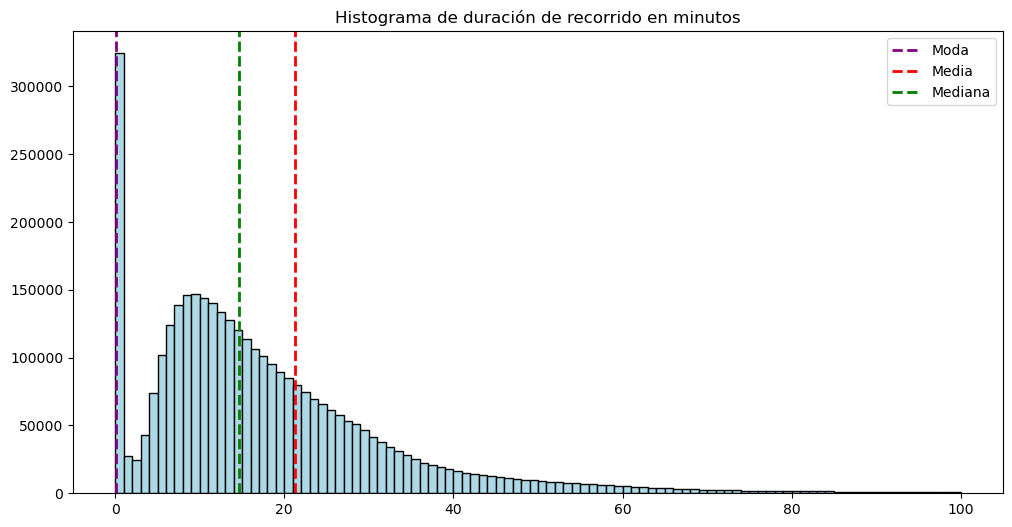

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_histograma(dataframe=ecobici_df, ax=ax, parametro='duracion_recorrido', titulo="Histograma de duración de recorrido en minutos")

plt.show()

Adicionalmente, se muestra la distribución de porcentajes de registros de viajes entre distintos intervalos por tiempo

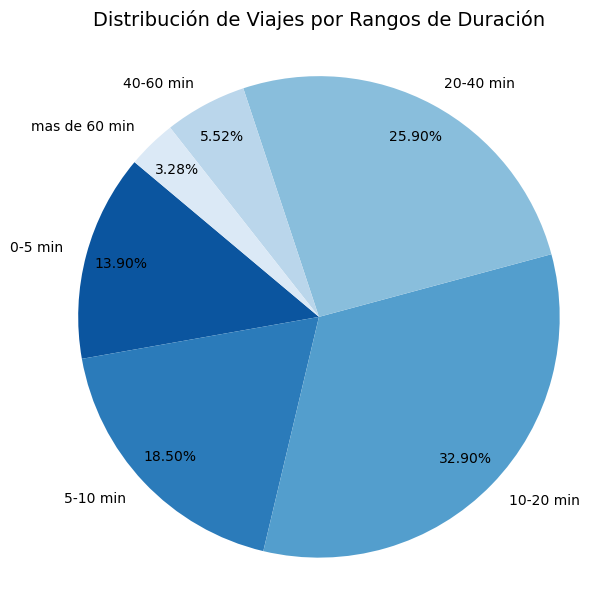

In [11]:
# Se definen intervalos en minutos
cortes = [0, 5, 10, 20, 40, 60, float('inf')]
etiquetas = ['0-5 min', '5-10 min', '10-20 min', '20-40 min', '40-60 min', 'mas de 60 min']

intervalos = pd.cut(ecobici_df['duracion_recorrido'], bins=cortes, labels=etiquetas, include_lowest=True)
conteo_absoluto = intervalos.value_counts().sort_index()

plt.figure(figsize=(6, 6))

colores = sns.color_palette('Blues_r', len(etiquetas)) 

plt.pie(
    conteo_absoluto,
    labels=conteo_absoluto.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=colores,
    pctdistance=0.85, # Aleja un poco los porcentajes del centro para que no se encimen
    textprops={'fontsize': 10}
)

plt.title('Distribución de Viajes por Rangos de Duración', fontsize=14, pad=20)
plt.axis('equal')  
plt.tight_layout()
plt.show()

##### **Tratamiento de outliers para variable duracion_recorrido**

#### Ajuste superior e inferior de duraciones

Tratándose de una distribución altamente asimétrica, se utiliza la fórmula ajustada con parámetros exponenciales de Hubert y Vandervieren _(Hubert, M. & Vandervieren, E., 2008. "An adjusted boxplot for skewed distributions," Computational Statistics & Data Analysis, Elsevier, vol. 52(12), pages 5186-5201, August.)_

Se calcula entonces el valor de medcouple

In [12]:
duraciones_de_recorridos = ecobici_df['duracion_recorrido'].dropna()

total = 0

muestra_duraciones = duraciones_de_recorridos.sample(n=10000, random_state=42).values    
mc_estimado = sms.medcouple(muestra_duraciones)

print(f"El medcouple (MC) estimado de los datos es: {mc_estimado:.4f}")

El medcouple (MC) estimado de los datos es: 0.2357


Dado que $MC > 0$ los límites ajustados ($L_I$ y $L_S$) se calculan como:
$$L_I = Q_1 - 1.5 \cdot e^{-4 \cdot MC} \cdot IQR$$
$$L_S = Q_3 + 1.5 \cdot e^{3 \cdot MC} \cdot IQR$$

In [13]:
# Fórmula con corrección exponencial
limite_inferior_con_correccion_exponencial = duracion_recorrido_Q1 - 1.5 * math.exp(-4 * mc_estimado) * duracion_recorrido_IQR
limite_superior_con_correccion_exponencial = duracion_recorrido_Q3 + 1.5 * math.exp(3 * mc_estimado) * duracion_recorrido_IQR

print(f"Límite inferior con corrección: {limite_inferior_con_correccion_exponencial:.3f}")
print(f"Límite superior con corrección: {limite_superior_con_correccion_exponencial:.4f}")

Límite inferior con corrección: -1.338
Límite superior con corrección: 74.3012


Dado que el límite inferior es un valor muy pequeño se decide considerar solamente valores entre 3 y 74 minutos

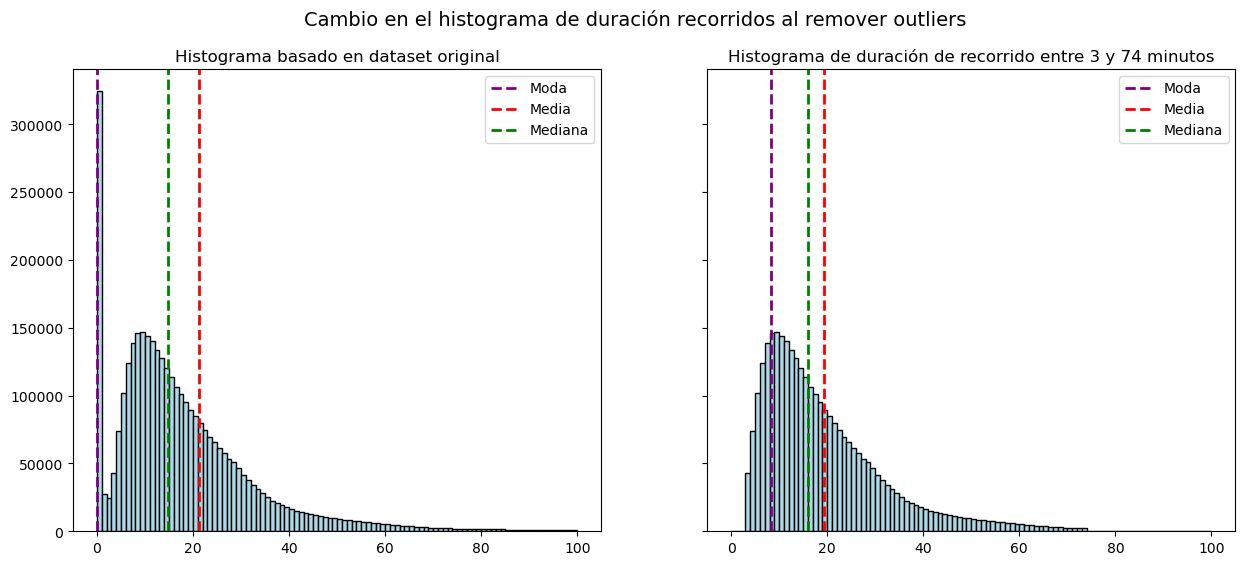

In [14]:
ecobici_filtrado_df = ecobici_df[(ecobici_df['duracion_recorrido'] > 3) & (ecobici_df['duracion_recorrido'] < 74)].copy()

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax.flatten()

plt.suptitle('Cambio en el histograma de duración recorridos al remover outliers', fontsize=14)

plot_histograma(dataframe=ecobici_df, ax=ax[0], parametro='duracion_recorrido', titulo="Histograma basado en dataset original")
plot_histograma(dataframe=ecobici_filtrado_df, ax=ax[1], parametro='duracion_recorrido', titulo="Histograma de duración de recorrido entre 3 y 74 minutos")

In [15]:
print("Nuevas estadísticas con dataset sin outliers de duración de recorridos:")

print(f"Media: {ecobici_filtrado_df['duracion_recorrido'].mean()}, {aclaracion_tiempo(ecobici_filtrado_df['duracion_recorrido'].mean())}")
print(f"Mediana: {ecobici_filtrado_df['duracion_recorrido'].median()}, {aclaracion_tiempo(ecobici_filtrado_df['duracion_recorrido'].median())}")
for i, moda in enumerate(ecobici_filtrado_df['duracion_recorrido'].mode(), 1):
    tiempo_legible = aclaracion_tiempo(moda)
    print(f"Moda {i}: {moda} {tiempo_legible}")

# Estadística robusta
duracion_recorrido_Q1, duracion_recorrido_Q2, duracion_recorrido_Q3 = cuartiles(ecobici_filtrado_df['duracion_recorrido'])

print()
print("Estadística robusta:")
print("Q1 (25%):", duracion_recorrido_Q1, aclaracion_tiempo(duracion_recorrido_Q1))
print("Q2 (Mediana, 50%):", duracion_recorrido_Q2, aclaracion_tiempo(duracion_recorrido_Q2))
print("Q3 (75%):", duracion_recorrido_Q3, aclaracion_tiempo(duracion_recorrido_Q3))

print()
print(f"Asímetría de la variable 'duracion_recorrido': {ecobici_filtrado_df['duracion_recorrido'].skew():.4f}")
print(f"Curtosis de la variable 'duracion_recorrido': {ecobici_filtrado_df['duracion_recorrido'].kurtosis():.4f}")

Nuevas estadísticas con dataset sin outliers de duración de recorridos:
Media: 19.431454057806487, (19 minutos 25 segundos)
Mediana: 16.016666666666666, (16 minutos 0 segundos)
Moda 1: 8.333333333333334 (8 minutos 20 segundos)

Estadística robusta:
Q1 (25%): 10.016666666666667 (10 minutos 1 segundos)
Q2 (Mediana, 50%): 16.016666666666666 (16 minutos 0 segundos)
Q3 (75%): 25.233333333333334 (25 minutos 14 segundos)

Asímetría de la variable 'duracion_recorrido': 1.4378
Curtosis de la variable 'duracion_recorrido': 2.1823


Text(0.5, 1.0, 'Histograma luego de limpieza de duracion de recorridos')

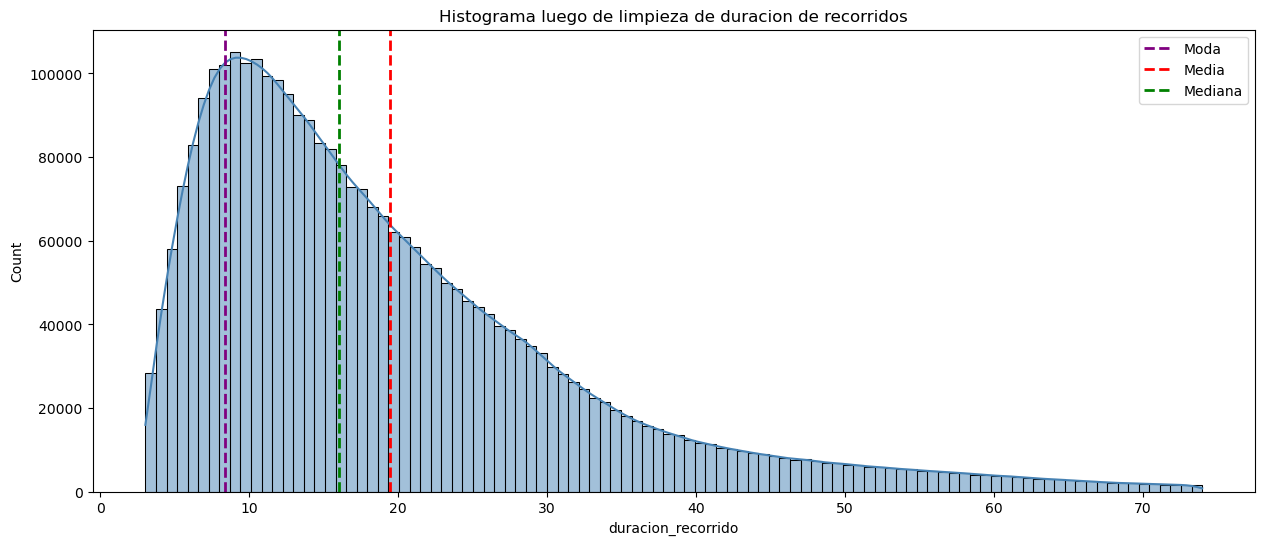

In [16]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.histplot(ecobici_filtrado_df, x='duracion_recorrido', bins=100, kde=True, ax=ax, color='steelblue')
ax.axvline(ecobici_filtrado_df['duracion_recorrido'].mode()[0], color='purple', ls='--', lw=2, label='Moda')
ax.axvline(ecobici_filtrado_df['duracion_recorrido'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(ecobici_filtrado_df['duracion_recorrido'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.legend()
ax.set_title("Histograma luego de limpieza de duracion de recorridos")

In [17]:
# Se asigna el dataframe limpio al dataframe original
ecobici_df = ecobici_filtrado_df

#### **Variable género**

In [18]:
def plot_pie(data, column, mapa_colores, ax=None, startangle=90, title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    # Mapeamos los colores en el mismo orden exacto en que quedaron las categorías en 'counts'
    colores_ordenados = [mapa_colores[cat] for cat in counts.index]
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=colores_ordenados  # Usamos los colores sincronizados
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal')

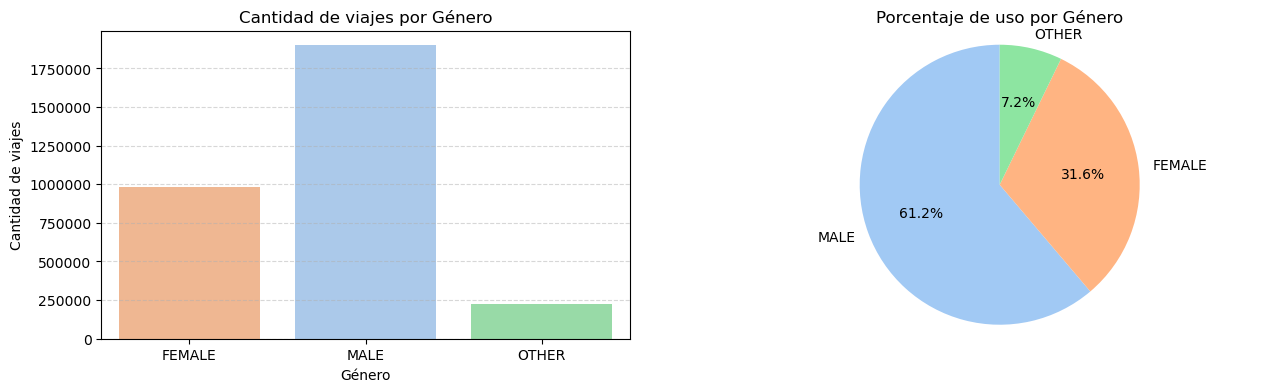

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes = axes.flatten()

paleta_base = sns.color_palette('pastel')

colores_genero = {
    'MALE':     paleta_base[0],
    'FEMALE':   paleta_base[1],
    'OTHER':    paleta_base[2]  
}

# Grafico 1: Barras
sns.countplot(
    x='genero', 
    data=ecobici_df, 
    hue='genero', 
    palette=colores_genero,
    ax=axes[0], 
    legend=False,
    dodge=False
)
axes[0].set_title('Cantidad de viajes por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].grid(axis='y', ls='--', alpha=0.5)
axes[0].ticklabel_format(style='plain', axis='y')

# Grafico 2: Pie chart
plot_pie(
    data=ecobici_df, 
    column='genero', 
    mapa_colores=colores_genero,
    ax=axes[1], 
    title='Porcentaje de uso por Género'
)

#### **Variable modelo de bicicleta**

In [20]:
print(ecobici_df['modelo_bicicleta'].value_counts())

modelo_bicicleta
FIT       2235944
ICONIC     877951
Name: count, dtype: int64


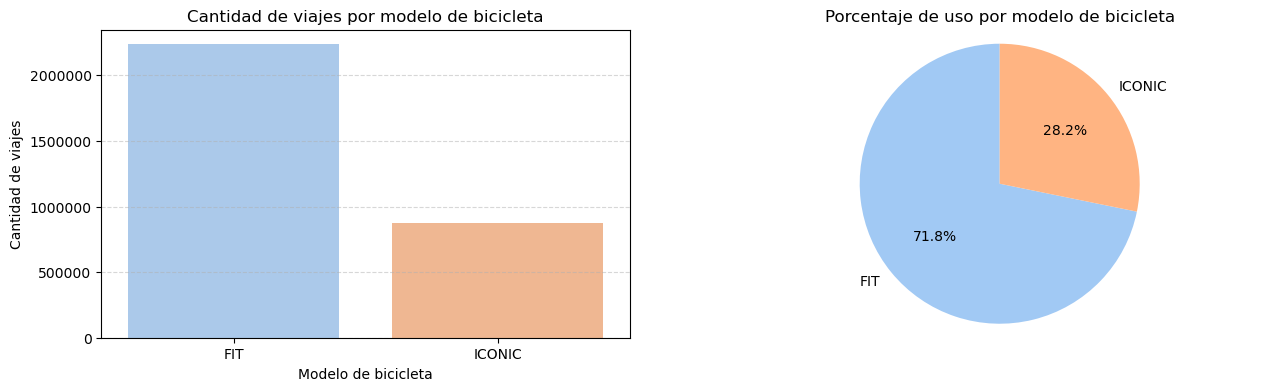

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes = axes.flatten()

paleta_base = sns.color_palette('pastel')

colores_bicicletas = {
    'FIT':     paleta_base[0],
    'ICONIC':   paleta_base[1],
}

# Grafico 1: Barras
sns.countplot(
    x='modelo_bicicleta', 
    data=ecobici_df, 
    hue='modelo_bicicleta', 
    palette=colores_bicicletas,
    ax=axes[0], 
    legend=False,
    dodge=False
)
axes[0].set_title('Cantidad de viajes por modelo de bicicleta')
axes[0].set_xlabel('Modelo de bicicleta')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].grid(axis='y', ls='--', alpha=0.5)
axes[0].ticklabel_format(style='plain', axis='y')

# Grafico 2: Pie chart
plot_pie(
    data=ecobici_df, 
    column='modelo_bicicleta', 
    mapa_colores=colores_bicicletas,
    ax=axes[1], 
    title='Porcentaje de uso por modelo de bicicleta'
)

#### **Variables de estaciones de origen y destino**

Nota: los datos para graficar el contorno de CABA fueron descargados desde https://data.buenosaires.gob.ar/dataset/barrios/resource/1c3d185b-fdc9-474b-b41b-9bd960a3806e

In [22]:
# Se agrupan por estación de origen para tener coordenadas únicas y contar cuántos viajes salen de cada una
estaciones = (
    ecobici_df.groupby('nombre_estacion_origen')
    .agg(
        long=('long_estacion_origen', 'first'),
        lat=('lat_estacion_origen', 'first'),
        total_viajes=('id_recorrido', 'count')
    )
    .reset_index()
    .dropna() # por las dudas si hay alguna sin coordenadas
)

print(estaciones.head())

# Se crea la geometría de puntos geométricos espaciales
geometria = gpd.points_from_xy(estaciones['long'], estaciones['lat'])

# Se transforma a GeoDataFrame
geo_estaciones = gpd.GeoDataFrame(estaciones, geometry=geometria, crs="EPSG:4326")

# Se carga el mapa de los barrios de CABA
mapa_caba = gpd.read_file('./geojson/barrios.geojson')

      nombre_estacion_origen       long        lat  total_viajes
0          -CDO CUCHA CUCHA- -58.390287 -34.654474           228
1  001 - FACULTAD DE DERECHO -58.390602 -34.583749         26526
2             002 - Retiro I -58.374710 -34.592424          9633
3               003 - ADUANA -58.369129 -34.612207         15802
4           004 - Plaza Roma -58.368856 -34.603008         18651


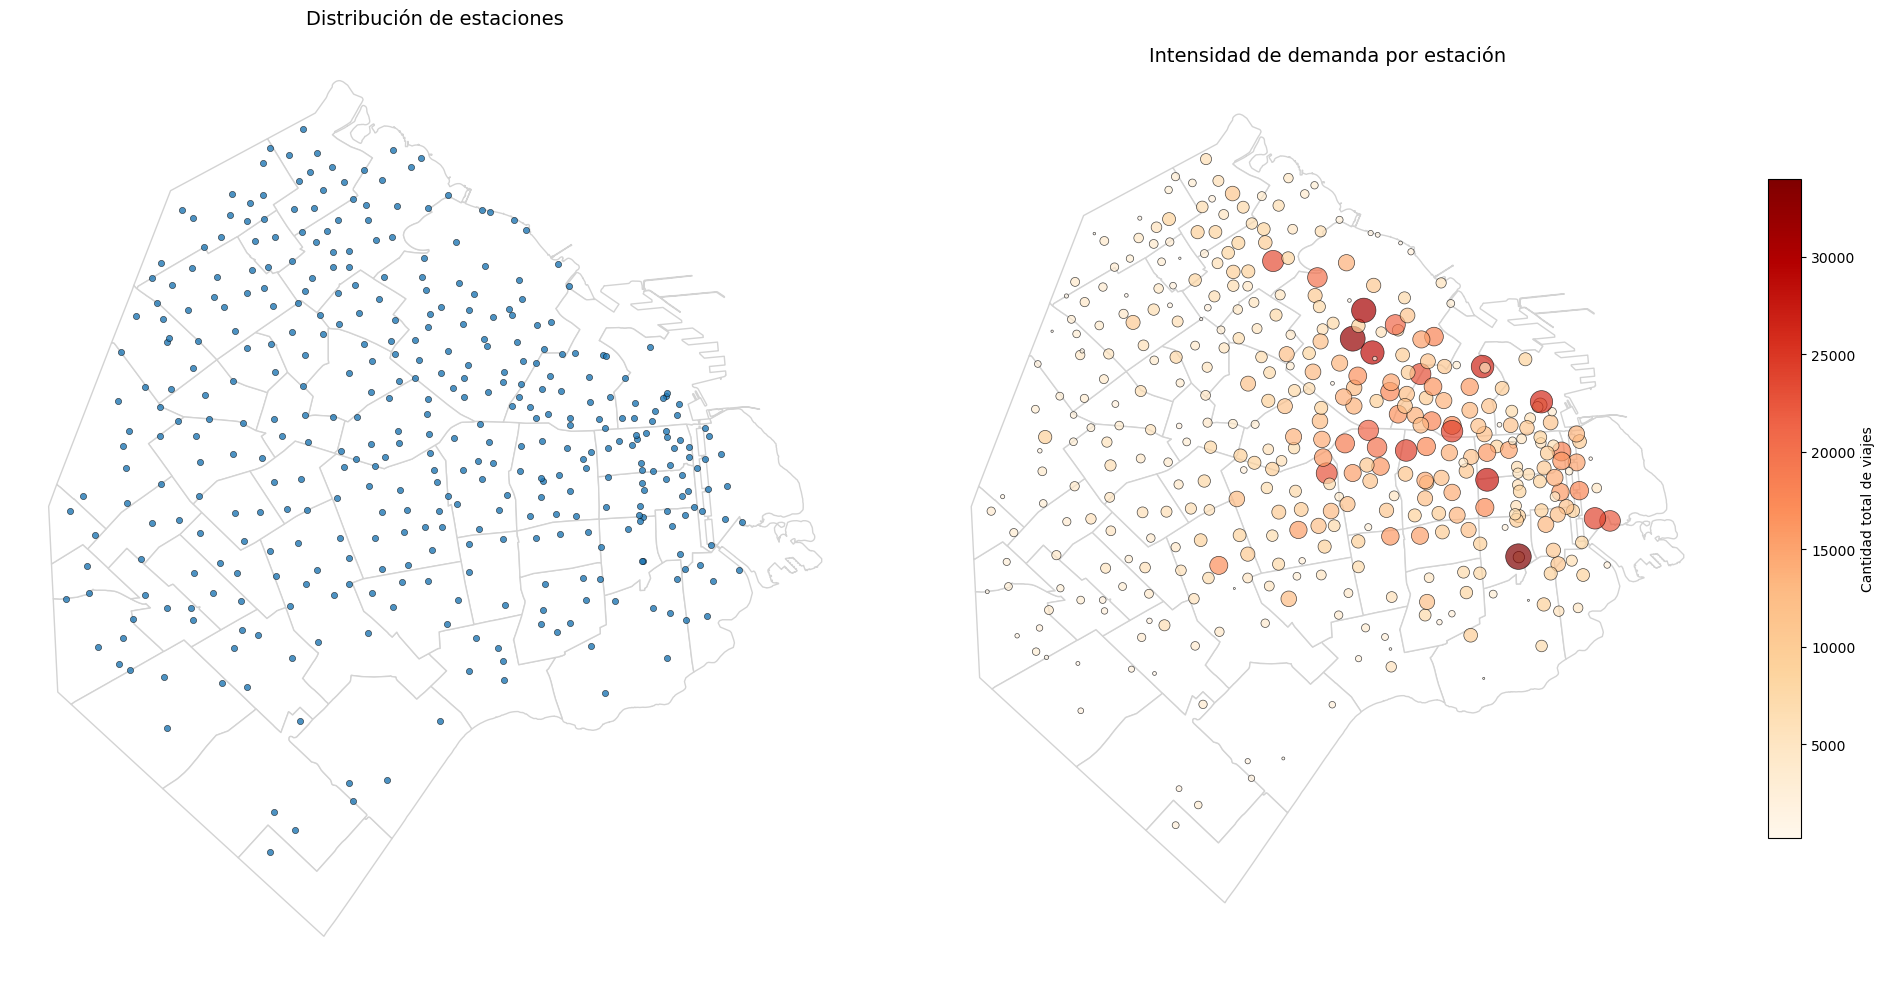

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: infraestructura. Se dibuja el fondo de CABA
mapa_caba.plot(ax=axes[0], color='white', edgecolor='lightgrey')

# Se dibujan las estaciones todas iguales
geo_estaciones.plot(
    ax=axes[0], 
    color='#1F77B4',
    markersize=20,   # Todos los puntos del mismo tamaño
    alpha=0.8, 
    edgecolor='black', 
    linewidth=0.4
)
axes[0].set_title('Distribución de estaciones', fontsize=14, pad=10)
axes[0].axis('off')  # Se sacan los ejes


# Mapa 2: mapa de calor (demanda de las estaciones). Se dibuja el fondo de CABA
mapa_caba.plot(ax=axes[1], color='white', edgecolor='lightgrey')

# Se dibuja el mapa de calor
geo_estaciones.plot(
    ax=axes[1], 
    column='total_viajes', 
    cmap='OrRd',       
    legend=True,       
    legend_kwds={'label': "Cantidad total de viajes", 'orientation': "vertical", 'shrink': 0.7},
    markersize=geo_estaciones['total_viajes'] / 100, # Ajustado para que no se pisen tanto
    alpha=0.7, 
    edgecolor='black', 
    linewidth=0.5
)
axes[1].set_title('Intensidad de demanda por estación', fontsize=14, pad=10)
axes[1].axis('off')  # Se sacan los ejes

plt.tight_layout()
plt.show()

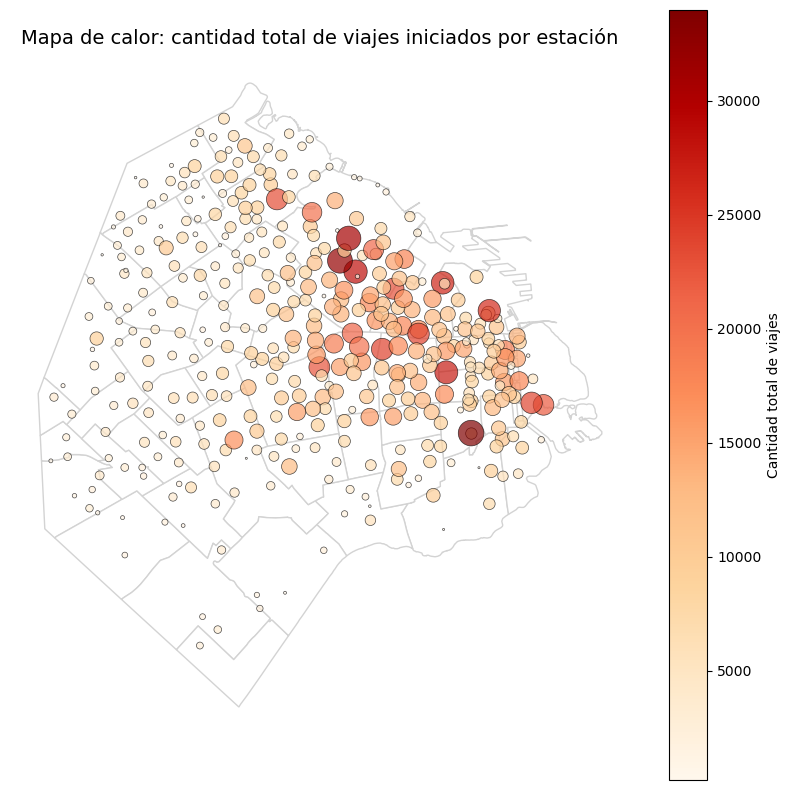

In [24]:
# Se crea el gráfico
fig, ax = plt.subplots(figsize=(10, 10))

# Se dibuja el fondo de los barrios en gris claro
mapa_caba.plot(ax=ax, color='white', edgecolor='lightgrey')

# Se dibujan las estaciones
geo_estaciones.plot(
    ax=ax, 
    column='total_viajes', 
    cmap='OrRd',       # Paleta de blanco a rojo oscuro
    legend=True,       # Muestra la barra de escala de colores
    markersize=geo_estaciones['total_viajes'] / 100, # Divisor para agrandar/achicar puntos
    legend_kwds={'label': "Cantidad total de viajes", 'orientation': "vertical"},
    alpha=0.7, 
    edgecolor='black', 
    linewidth=0.5
)

ax.set_title('Mapa de calor: cantidad total de viajes iniciados por estación', fontsize=14)
ax.axis('off') # Se saca los ejes de latitud y longitud

plt.show()

#### **Variables de fechas de los recorridos**

Se inicia la exploración de las fechas de los recorridos con la creación de algunas columnas necesarias para discernir: días, fechas, días de la semana de días de los fines de semana, días feriados, etc. Para ello, __solo se considerará la fecha origen de los viajes__ y se tomará como representativa del recorrido

In [25]:
# Conversion a datetime de fechas formato AAAA-MM-DD hh:mm
ecobici_df['fecha_origen_recorrido'] = pd.to_datetime(ecobici_df['fecha_origen_recorrido'])

In [26]:
# Creación de columnas nuevas con la fecha únicamente: se extrae AAAA-MM-DD
ecobici_df['fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.date

# Creación de columnas para saber el día de la semana
ecobici_df['dia_de_la_semana_fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.dayofweek

# Creación de columna categórica binaria para saber si es fin de semana (0 es lunes, 1 es martes,... 5 es sabado, 6 es domingo)
ecobici_df['fecha_origen_es_finde'] = ecobici_df['dia_de_la_semana_fecha_origen'].isin([5, 6])

# Creación de columna con el nombre del día (monday, tuesday, etc)
ecobici_df['nombre_del_dia_fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.day_name()

In [27]:
ecobici_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,...,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,fecha_origen,dia_de_la_semana_fecha_origen,fecha_origen_es_finde,nombre_del_dia_fecha_origen
0,20428222,9.466667,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,...,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE,2024-01-23,1,False,Tuesday
1,20431744,22.583333,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,...,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE,2024-01-23,1,False,Tuesday
4,20424802,11.333333,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,...,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE,2024-01-23,1,False,Tuesday
5,20427241,7.766667,2024-01-23 17:48:05,99,099 - Malabia,780 Malabia & Loyola,-58.435408,-34.596096,2024-01-23 17:55:51,206,...,Fitz Roy & Gorriti,-58.437339,-34.584950,320714.0,FIT,OTHER,2024-01-23,1,False,Tuesday
6,20431004,19.600000,2024-01-23 21:17:38,68,105 - PARQUE SAAVEDRA,García del Río 3590,-58.480464,-34.552148,2024-01-23 21:37:14,68,...,García del Río 3590,-58.480464,-34.552148,1041602.0,ICONIC,MALE,2024-01-23,1,False,Tuesday


In [28]:
# Se cuentan cuántos viajes hubo por cada fecha individual, separando si fue finde o no
viajes_por_dia = ecobici_df.groupby(['fecha_origen', 'fecha_origen_es_finde']).size().reset_index(name='cantidad_viajes')

# Se calcula el promedio de viajes diarios para cada tipo de día
promedio_demanda = viajes_por_dia.groupby('fecha_origen_es_finde')['cantidad_viajes'].mean()

print("Promedio de viajes diarios")
print(f"Días Hábiles (Lunes a Viernes): {promedio_demanda[False]:.0f} viajes por día")
print(f"Fines de Semana (Sábado y Domingo): {promedio_demanda[True]:.0f} viajes por día")

Promedio de viajes diarios
Días Hábiles (Lunes a Viernes): 10389 viajes por día
Fines de Semana (Sábado y Domingo): 3769 viajes por día


Se encuentra que __en los días hábiles hay casi el triple de viajes diarios que los fines de semana__ (casi 12.000 contra 4.500).  
Una posible conclusión de este dato es que __Ecobici no es un sistema principalmente recreativo o turístico__, sino __parte del medio de transporte público para conmutar__. Los fines de semana la demanda se desplomaría ya que las personas no tienen que cumplir horarios laborales.

In [29]:
feriados_argentina_2024 = [
    '2024-01-01', # Año nuevo
    '2024-02-12', # Carnaval
    '2024-02-13', # Carnaval
    '2024-03-24', # Día Nacional de la Memoria por la Verdad y la Justicia
    '2024-03-28', # Jueves Santo
    '2024-03-29', # Viernes Santo
    '2024-04-01', # Feriado con fines turísticos
    '2024-04-02', # Día del Veterano y de los Caídos en la Guerra de Malvinas
    '2024-05-01', # Día del trabajo
    '2024-05-25', # Revolución de Mayo
    '2024-06-17', # Paso a la Inmortalidad del General Don Martín Miguel de Güemes
    '2024-06-20', # Paso a la Inmortalidad del General Don Manuel Belgrano
    '2024-06-21', # Feriado con fines turísticos
    '2024-07-09', # Día de la Independencia
    '2024-08-17', # Paso a la Inmortalidad del General Don José de San Martín
    '2024-10-11', # Feriado con fines turísticos
    '2024-11-18', # Día de la Soberanía
    '2024-12-25', # Navidad
]

feriados_argentina_2024_dates = pd.to_datetime(feriados_argentina_2024).date

# Se crea la columna en el dataset
ecobici_df['fecha_origen_es_feriado'] = ecobici_df['fecha_origen'].isin(feriados_argentina_2024_dates)

In [30]:
# Se crea una columna para indicar qué tipo de día es cada fecha origen
def etiquetar_tipo_dia_origen(row):
    if row['fecha_origen_es_feriado']:
        return 'Feriado'
    elif row['fecha_origen_es_finde']:
        return 'Fin de Semana'
    else:
        return 'Día Hábil'

ecobici_df['tipo_fecha_origen'] = ecobici_df.apply(etiquetar_tipo_dia_origen, axis=1)

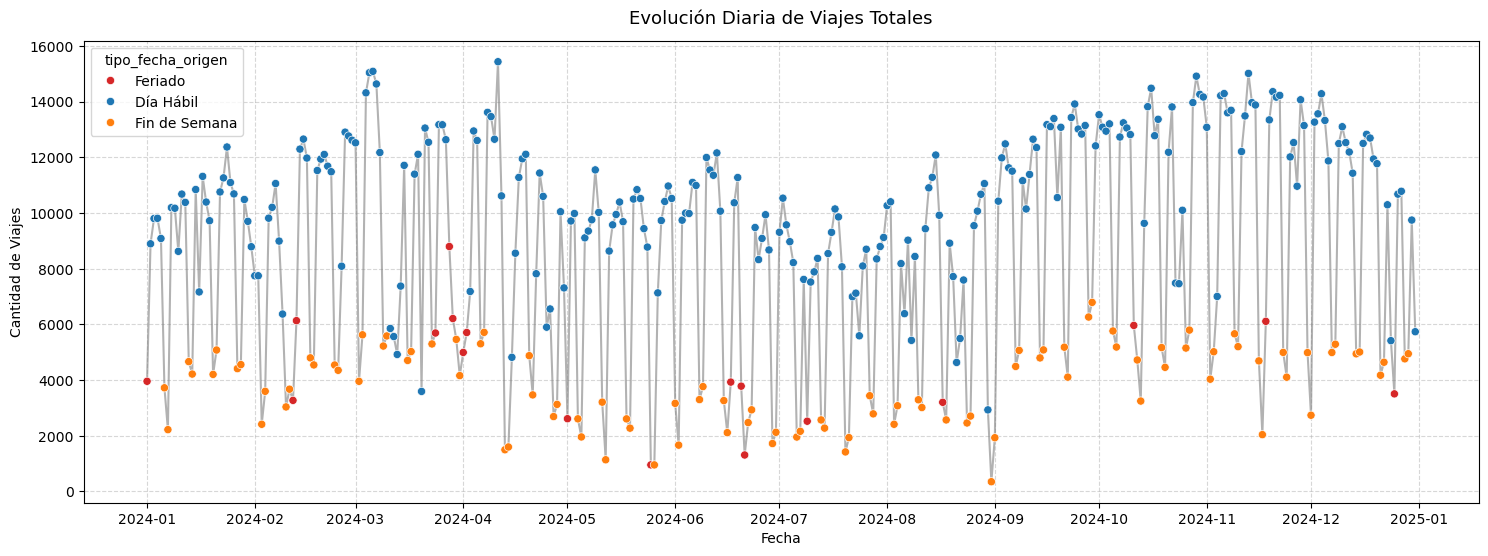

In [42]:
fig, ax = plt.subplots(figsize=(18, 6))

paleta = {'Día Hábil': '#1F77B4', 'Fin de Semana': '#FF7F0E', 'Feriado': '#D62728'}

# Grafico 1: serie temporal. Cantidad de viajes por día distinguiendo:
# - Días de semana
# - Días de fin de semana
# - Días feriados
df_temporal = ecobici_df.groupby('fecha_origen').size().reset_index(name='cantidad_viajes')

df_temporal['fecha_origen'] = pd.to_datetime(df_temporal['fecha_origen'])

# Datos para los promedios (Gráfico 2)
df_promedios_dia = ecobici_df.groupby(['fecha_origen', 'tipo_fecha_origen']).size().reset_index(name='cantidad_viajes')
df_promedios = df_promedios_dia.groupby('tipo_fecha_origen')['cantidad_viajes'].mean().reset_index()

# Categorías para el gráfico de barras
orden_dias = ['Día Hábil', 'Fin de Semana', 'Feriado']

sns.lineplot(
    data=df_temporal, 
    x='fecha_origen', 
    y='cantidad_viajes', 
    ax=ax, 
    color='grey', 
    alpha=0.6, 
    lw=1.5
)
# Puntos de color según el tipo de día
df_temporal_tipo = ecobici_df.groupby(['fecha_origen', 'tipo_fecha_origen']).size().reset_index(name='cantidad_viajes')
df_temporal_tipo['fecha_origen'] = pd.to_datetime(df_temporal_tipo['fecha_origen'])

sns.scatterplot(
    data=df_temporal_tipo, 
    x='fecha_origen', 
    y='cantidad_viajes', 
    hue='tipo_fecha_origen', 
    palette=paleta, 
    ax=ax, 
    s=35, 
    zorder=3
)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.set_title('Evolución Diaria de Viajes Totales', fontsize=13, pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de Viajes')
ax.grid(True, ls='--', alpha=0.5)

Observaciones
- Se nota una tendencia de disminución de viajes durante las épocas del centro del gráfico. Una posible hipótesis es que este comportamiento se debaa las bajas temperaturas (en época invernal los usuarios preferirían otros medios de transporte)
- La actividad durante los feriados y fines de semana decae de acuerdo a lo previamente calculado: en promedio la actividad durante días laborales es aproximadamente el triple que los días no laborables

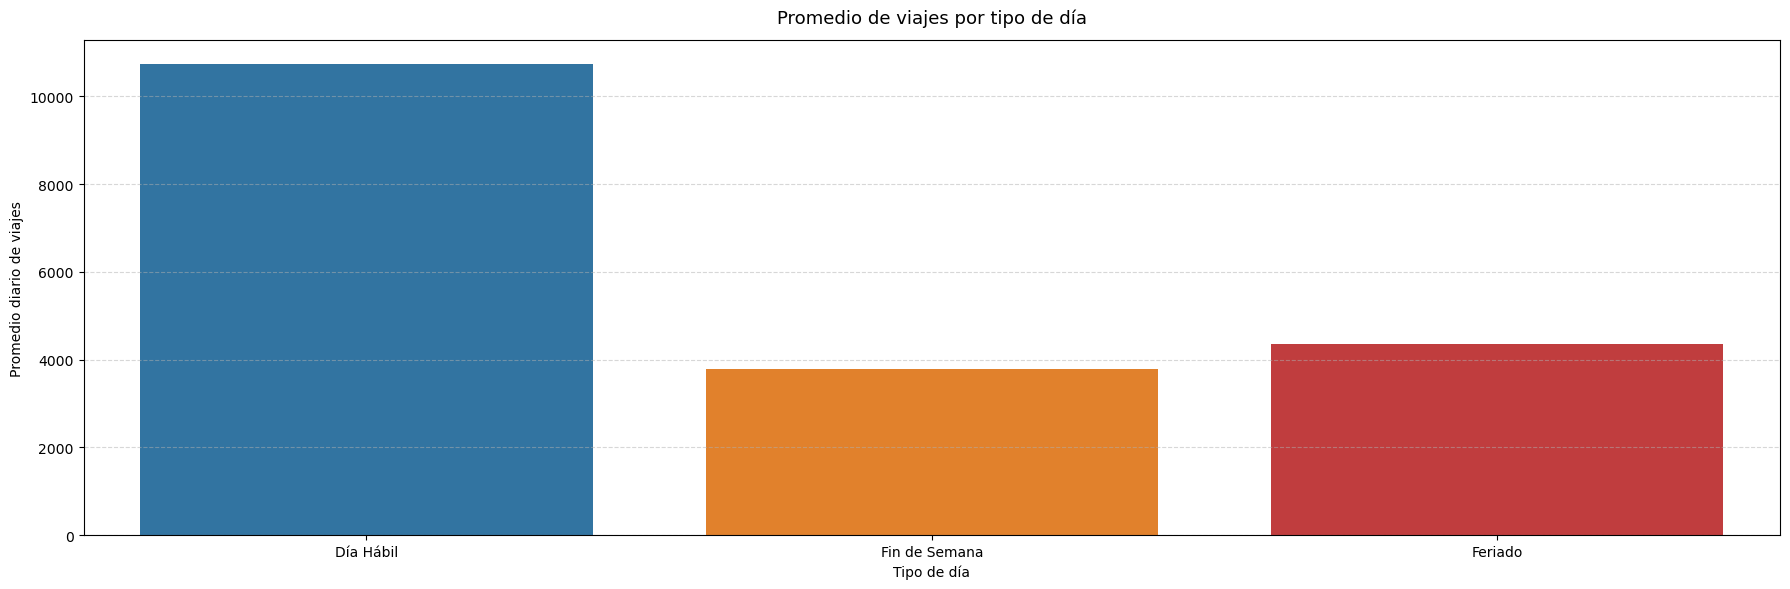

In [40]:
fig, ax = plt.subplots(figsize=(18, 6))

# Grafico 2: gráfico de barras por cantidad de viajes diferenciando por día
sns.barplot(
    data=df_promedios, 
    x='tipo_fecha_origen', 
    y='cantidad_viajes', 
    order=orden_dias, 
    palette=paleta, 
    hue='tipo_fecha_origen',
    dodge=False,
    ax=ax,
    legend=False
)

# Etiquetas con el número exacto arriba de cada barra para que sea fácil de leer
for p in axes[1].patches:
    height = p.get_height()
    if height > 0: # Evita errores si alguna barra queda vacía
        axes[1].annotate(f'{height:.0f}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de despegue vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Promedio de viajes por tipo de día', fontsize=13, pad=12)
ax.set_xlabel('Tipo de día')
ax.set_ylabel('Promedio diario de viajes')
ax.grid(axis='y', ls='--', alpha=0.5)

# Ajustes generales
plt.tight_layout()
plt.show()

### - Plantear un posible problema de ML supervisado a partir de los datos elegidos. Describir el problema de clasificación o de regresión. Definir la variable target.

Como posible problema de ML se plantea __un problema de regresión__. La variable target será __"duración_recorrido"__, es decir, se tratará de predecir la duración de un viaje conocidas las otras variables.

## Preprocesamiento y limpieza del dataset

### - Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.

### - Realizar el split del dataset (ej: train y test).


### - Identificar y tratar los valores faltantes en el dataset.

### - Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.

### - Escalar/normalizar los features.

## Feature engineering

### - Crear nuevos features en caso de ser necesario. Justificar.

### - Aplicar técnicas de conversión de variables: codificación, discretización.

### - Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).

### - Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

## Reducción de dimensionalidad

### - Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).

### - Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción.